# Differentiable design of a pair-conversion tracker with an anticoincidence detector (ACD)

**Setup.** A point source with a power-law spectrum (index 2, truncated between 100 MeV and 10 GeV, in 4 energy bins
per decade) hits the detector at normal incidence. The detector is a stack of tungsten converter layers, each followed
by two silicon strip planes (x and y), wrapped in a plastic scintillator ACD that vetoes charged particles. The energy is
assumed known perfectly (no energy migration). The old monochromatic source is kept: `setSourceType("monochromatic")`.

**Goal.** Choose the geometry that maximises the test statistic (TS) of a point-like signal on top of a diffuse
photon background and a charged-particle background, as Fermi-LAT does for its sensitivity.

**Method.** The whole detector response is a closed-form, differentiable function of the design parameters,
so JAX can give us the gradient of the significance with respect to every parameter and Adam can climb it.
The TS is the expected (Asimov) likelihood ratio of the data with and without a point source, integrated
over the sky around the source. Each conversion layer in each energy bin is its own pseudo-detector with its own PSF,
and the results are summed over layers and energy bins, which is the TS of a power-law fit against the background-only
fit (see the README for the reasoning). The old single-cone count is kept as a check.
All numbers are placeholders: set realistic ones before trusting any optimum.

**Naming.** camelCase everywhere, no unit suffixes. ACD is treated as a word (`acdThickness`).

**Units.** Lengths in cm, energies in MeV, times in s, solid angles in sr, fluxes in 1/(cm^2 s).
Angular variances are in rad^2. The angular resolution reported in the plots is in degrees.
Units are also given at the end of the line where each input is defined.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# The fixed inputs (with their sources) and all the formulas live in trackerUtils.py, next to this notebook.
# It also switches on 64-bit floats: the significance formula subtracts large, similar numbers, and float32 loses precision there.
from trackerUtils import *

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Fixed inputs
These are not optimised. If the optimiser could change them it would simply run to the bounds.
They are at the top of [trackerUtils.py](trackerUtils.py), each followed by its unit and its source.

In [2]:
# The fixed inputs are defined in trackerUtils.py and were imported above. To change one for an experiment, set it on the module
# before the first call that uses it, for example: import trackerUtils; trackerUtils.downstreamScatteringWeight = 0.0
if sourceType == "powerLaw":
    sourceDescription = f"power law, index {signalSpectralIndex}, {energyMinimum:.0f} to {energyMaximum:.0f} MeV in {numberOfEnergyBins} bins"
else:
    sourceDescription = f"monochromatic, {photonEnergy:.0f} MeV"
print(f"{numberOfLayers} layers, {numberOfReconstructableLayers} conversion-layer classes, source: {sourceDescription}, field of view {fieldOfViewSolidAngle} sr")

10 layers, 8 conversion-layer classes, source: power law, index 2.0, 100 to 10000 MeV in 8 bins, field of view 1.0 sr


## Detector model

The optimiser works on *unbounded* numbers. A sigmoid maps each one into its allowed range, so the
parameters can never leave the physical region and no clipping (which has zero gradient) is needed.
The mapping and the whole detector model are in [trackerUtils.py](trackerUtils.py).

## Checks of the spatial objective
A single Gaussian class in the background-dominated limit has the closed form `Z^2 = S^2 / (4 pi sigma^2 b)`, with `b`
the background density. A cone of 2 sigma keeps `1 - exp(-2) = 86.5%` of the signal and loses that factor in
significance against the spatial integral, so the ratio of the two should be `1 / 0.8647 = 1.1565`.
Splitting a sample into classes can only add information, so classes with labels must beat the same sample without.

In [3]:
testSignal, testBackground, testVariance = 100.0, 1e6, 0.1**2   # Test values chosen for the check, no physical source. Counts, counts over the field of view, rad^2.
oneClass = jnp.eye(1)
spatialSquared = computeSpatialSignificanceSquared(jnp.array([testSignal]), jnp.array([testBackground]), jnp.array([testVariance]), oneClass)
analyticSquared = testSignal**2 / (4.0 * jnp.pi * testVariance * testBackground / fieldOfViewSolidAngle)
print(f"spatial / analytic limit: {float(spatialSquared / analyticSquared):.5f}   (expected 1 minus about sigma^2/6 = 0.0017, from the curvature of the sky)")

# The same source analysed with a cone of 2 sigma, using the notebook's cone formulas.
coneSignalCount = testSignal * (1.0 - jnp.exp(-signalConeRadiusInSigma**2 / 2.0))
coneBackgroundCount = testBackground * jnp.pi * signalConeRadiusInSigma**2 * testVariance / fieldOfViewSolidAngle
ratio = jnp.sqrt(spatialSquared) / computeAsimovSignificance(coneSignalCount, coneBackgroundCount)
print(f"spatial / 2-sigma cone significance: {float(ratio):.4f}   (expected 1.1565, slightly lower from the curvature of the sky)")

# Splitting a sample into classes can only add information: two classes with different PSFs against their mixture.
twoVariances = jnp.array([0.05**2, 0.2**2])
twoSignals, twoBackgrounds = jnp.array([50.0, 50.0]), jnp.array([5e5, 5e5])
withLabels = computeSpatialSignificanceSquared(twoSignals, twoBackgrounds, twoVariances, jnp.eye(2))
withoutLabels = computeSpatialSignificanceSquared(twoSignals, twoBackgrounds, twoVariances, jnp.full((2, 2), 0.5))
print(f"two classes: with labels {float(jnp.sqrt(withLabels)):.4f} >= without labels {float(jnp.sqrt(withoutLabels)):.4f}")

# Mean path of its own foil that the pair crosses: closed form against numerical integration of the conversion depth, and against x / 2.
for foilRadiationLengths in (0.003, 0.1, 0.57):   # Thin, medium and thick foils, in radiation lengths. Test values, no physical source.
    depth = jnp.linspace(0.0, foilRadiationLengths, 20001)   # 20001: numerical choice, no physical source.
    absorptionWeight = jnp.exp(-pairConversionCoefficientPerRadiationLength * depth)
    numericalPath = foilRadiationLengths - jnp.trapezoid(depth * absorptionWeight, depth) / jnp.trapezoid(absorptionWeight, depth)
    closedForm = computeExpectedFoilPathAfterConversion(jnp.array(foilRadiationLengths))
    print(f"foil {foilRadiationLengths:5.3f} X0: closed form {float(closedForm):.6f}   numerical {float(numericalPath):.6f}   x/2 {foilRadiationLengths / 2:.6f}")

# Energy grid: the shares of the integral flux above energyMinimum in the bins add up to what the power law keeps below energyMaximum.
for indexName, index, fraction in (("signal", signalSpectralIndex, binSignalFraction), ("diffuse", diffuseSpectralIndex, binDiffuseFraction), ("charged", chargedSpectralIndex, binChargedFraction)):
    print(f"{indexName:8s} index {index}: bin shares sum to {float(jnp.sum(fraction)):.4f}   expected 1 - (Emax/Emin)^(1 - index) = {1.0 - (energyMaximum / energyMinimum) ** (1.0 - index):.4f}")

# The bound warnings must fire when the tracker is too large for the upper energy bound: lower energyMaximum to 1 GeV temporarily.
import trackerUtils
largestFoilDesign = {   # Test design: all foils at the upper bound. The numbers are unbounded values chosen for the test, no physical source.
    "converterThickness": jnp.full(numberOfLayers, 20.0), "layerSpacing": 1.1, "stripPitch": 1.1, "acdThickness": 1.1, "acdThreshold": 1.1,
}
originalEnergyMaximum = trackerUtils.energyMaximum
trackerUtils.energyMaximum = 1000.0   # MeV. Test value, no physical source.
print("warnings with all foils at the upper bound and energyMaximum = 1 GeV:", trackerUtils.computeBoundWarnings(largestFoilDesign))
trackerUtils.energyMaximum = originalEnergyMaximum
print("warnings with the real energyMaximum:", trackerUtils.computeBoundWarnings(largestFoilDesign))

spatial / analytic limit: 0.99798   (expected 1 minus about sigma^2/6 = 0.0017, from the curvature of the sky)


spatial / 2-sigma cone significance: 1.1555   (expected 1.1565, slightly lower from the curvature of the sky)


two classes: with labels 0.4108 >= without labels 0.3211


foil 0.003 X0: closed form 0.001501   numerical 0.001501   x/2 0.001500
foil 0.100 X0: closed form 0.050648   numerical 0.050648   x/2 0.050000
foil 0.570 X0: closed form 0.305990   numerical 0.305990   x/2 0.285000
signal   index 2.0: bin shares sum to 0.9900   expected 1 - (Emax/Emin)^(1 - index) = 0.9900
diffuse  index 2.1: bin shares sum to 0.9937   expected 1 - (Emax/Emin)^(1 - index) = 0.9937
charged  index 2.7: bin shares sum to 0.9996   expected 1 - (Emax/Emin)^(1 - index) = 0.9996


warnings with all foils at the upper bound and energyMaximum = 1 GeV: ['the tracker is too large for energyMaximum = 1000 MeV: it has 5.74 radiation lengths against a shower maximum at 5.33. The highest-energy photons shower inside it and the two-track pair model fails.', 'the truncation at energyMaximum discards about 1630 expected signal photons (more than 10).']
warnings with the real energyMaximum: ['the truncation at energyMaximum discards about 148 expected signal photons (more than 10).']


## Optimisation, recording the history
Every `recordingInterval` steps we store the metrics and the physical parameters, for the plots below.

In [4]:
def createInitialParameters(randomKey=None, randomSpread=0.0):
    """Zeros put every parameter at the middle of its range. A random key gives a random starting design."""
    if randomKey is None:
        return {
            "converterThickness": jnp.zeros(numberOfLayers),
            "layerSpacing": 1.1,   # Unbounded start value: sigmoid(1.1) = 0.75 of the range (not the middle, unlike zeros). Starting point only, no physical source.
            "stripPitch": 1.1,   # Unbounded start value: sigmoid(1.1) = 0.75 of the range (not the middle, unlike zeros). Starting point only, no physical source.
            "acdThickness": 1.1,   # Unbounded start value: sigmoid(1.1) = 0.75 of the range (not the middle, unlike zeros). Starting point only, no physical source.
            "acdThreshold": 1.1,   # Unbounded start value: sigmoid(1.1) = 0.75 of the range (not the middle, unlike zeros). Starting point only, no physical source.
        }
    keyForConverter, keyForSpacing, keyForPitch, keyForAcd, keyForThreshold = jax.random.split(randomKey, 5)   # 5: one random key per parameter group.
    return {
        "converterThickness": randomSpread * jax.random.normal(keyForConverter, (numberOfLayers,)),
        "layerSpacing": randomSpread * jax.random.normal(keyForSpacing),
        "stripPitch": randomSpread * jax.random.normal(keyForPitch),
        "acdThickness": randomSpread * jax.random.normal(keyForAcd),
        "acdThreshold": randomSpread * jax.random.normal(keyForThreshold),
    }


def runOptimisation(initialParameters, numberOfSteps=2000, learningRate=5e-2, recordingInterval=10):   # Optimiser settings: 2000 steps, Adam learning rate 5e-2, record every 10 steps. Numerical choices, no physical source.
    optimiser = optax.adam(learningRate)
    optimiserState = optimiser.init(initialParameters)

    @jax.jit
    def performOneStep(currentParameters, currentOptimiserState):
        lossValue, gradients = jax.value_and_grad(computeLoss)(currentParameters)   # Autodiff happens here.
        parameterUpdates, newOptimiserState = optimiser.update(gradients, currentOptimiserState)
        return optax.apply_updates(currentParameters, parameterUpdates), newOptimiserState

    currentParameters = initialParameters
    recordedHistory = {"loss": [], "physicalParameters": [], "metrics": []}
    for stepNumber in range(numberOfSteps):
        if stepNumber % recordingInterval == 0:
            metricsAtStep = computeMetrics(currentParameters)
            recordedHistory["metrics"].append({metricName: float(metricsAtStep[metricName]) for metricName in scalarMetricNames})
            recordedHistory["physicalParameters"].append(
                {parameterName: np.array(parameterValue) for parameterName, parameterValue in mapUnboundedToPhysicalParameters(currentParameters).items()}
            )
            recordedHistory["loss"].append(float(computeLoss(currentParameters)))
        currentParameters, optimiserState = performOneStep(currentParameters, optimiserState)
    return currentParameters, recordedHistory


recordingInterval = 10   # Steps between recorded metrics. Numerical choice, no physical source.
initialParameters = createInitialParameters()
optimisedParameters, optimisationHistory = runOptimisation(initialParameters, recordingInterval=recordingInterval)

initialMetrics = optimisationHistory["metrics"][0]
finalMetrics = {metricName: float(metricValue) for metricName, metricValue in computeMetrics(optimisedParameters).items() if metricValue.ndim == 0}
print(
    f"test statistic TS {initialMetrics['testStatistic']:.1f} -> {finalMetrics['testStatistic']:.1f}   "
    f"(Z = sqrt(TS) {initialMetrics['significance']:.2f} -> {finalMetrics['significance']:.2f}; 5 sigma is TS = {detectionTestStatistic:.0f})\n"
    f"no labels TS {finalMetrics['testStatisticNoLabel']:.1f}, single cone TS {finalMetrics['coneTestStatistic']:.1f}\n"
    f"signal photons {finalMetrics['totalSignalPhotons']:.1f}   "
    f"PSF68 {finalMetrics['psf68']:.2f} deg   PSF95 {finalMetrics['psf95']:.2f} deg"
)


test statistic TS 7188.6 -> 9616.2   (Z = sqrt(TS) 84.79 -> 98.06; 5 sigma is TS = 25)
no labels TS 9330.4, single cone TS 7891.8
signal photons 11261.5   PSF68 9.42 deg   PSF95 20.73 deg


In [5]:
optimisedParameters

{'acdThickness': Array(4.12705755, dtype=float64),
 'acdThreshold': Array(-0.50127958, dtype=float64),
 'converterThickness': Array([ 1.13147106,  0.04779856, -9.24855973, -9.25100341,  8.22047716,
        -9.39367184, -9.19180514,  7.55851891, -8.73261956, -8.85128602],      dtype=float64),
 'layerSpacing': Array(0.53090027, dtype=float64),
 'stripPitch': Array(-1.94761011, dtype=float64)}

In [6]:
mapUnboundedToPhysicalParameters(optimisedParameters)

{'converterThickness': Array([0.15146594, 0.10287753, 0.00101915, 0.00101911, 0.19994647,
        0.00101657, 0.00102027, 0.19989625, 0.00103208, 0.00102849],      dtype=float64),
 'layerSpacing': Array(3.33361878, dtype=float64),
 'stripPitch': Array(0.01685735, dtype=float64),
 'acdThickness': Array(2.96031446, dtype=float64),
 'acdThreshold': Array(0.40837801, dtype=float64)}

In [7]:
# Human-readable text report of the designs. Printed here and written to designReport.txt next to the notebook.
# The 0.01 and the widths below are reporting conventions with no physical source.
designReportPath = "designReport.txt"
micrometersPerCentimeter = 1e4   # Unit conversion.


def describeBoundStatus(value, lowerBound, upperBound):
    fractionOfRange = (value - lowerBound) / (upperBound - lowerBound)
    if fractionOfRange < 0.01:   # Within 1% of the range counts as at the bound.
        return "  <- at lower bound"
    if fractionOfRange > 0.99:
        return "  <- at upper bound"
    return ""


def formatDesignReport(designName, unboundedParameters):
    physicalParameters = mapUnboundedToPhysicalParameters(unboundedParameters)
    metrics = computeMetrics(unboundedParameters)
    converterThickness = physicalParameters["converterThickness"]
    converterRadiationLengths, radiationLengthsAboveLayer, radiationLengthsBelowLayer = computeLayerMaterial(converterThickness)
    conversionProbability = computeConversionProbabilityPerLayer(converterRadiationLengths, radiationLengthsAboveLayer)
    sigmaPerBinAndLayerDegrees = jnp.degrees(jnp.sqrt(computePerLayerAngularVarianceInEnergyBins(
        converterRadiationLengths, physicalParameters["layerSpacing"], physicalParameters["stripPitch"]
    )))   # One row per energy bin. The report shows the lowest and the highest bin.

    lines = [f"Design: {designName}", "=" * 60]
    if sourceType == "powerLaw":
        lines.append(f"Source: power law, index {signalSpectralIndex}, {energyMinimum:.0f} to {energyMaximum:.0f} MeV, {numberOfEnergyBins} bins, energy known perfectly")
    else:
        lines.append(f"Source: monochromatic, {photonEnergy:.0f} MeV")
    lines.append("Figures of merit")
    lines.append(f"  TS, per-layer classes (objective):           {float(metrics['testStatistic']):8.1f}   (Z = {float(metrics['significance']):.2f})")
    lines.append(f"  TS, no layer labels (lower bound):           {float(metrics['testStatisticNoLabel']):8.1f}   (Z = {float(metrics['significanceNoLabel']):.2f})")
    lines.append(f"  TS, single cone (check):                     {float(metrics['coneTestStatistic']):8.1f}   (Z = {float(metrics['coneSignificance']):.2f})")
    lines.append(f"  (a 5 sigma detection is TS = {detectionTestStatistic:.0f})")
    lines.append(f"  signal photons:                              {float(metrics['totalSignalPhotons']):8.1f}")
    lines.append(f"  total conversion probability:                {float(metrics['totalConversionProbability']):8.3f}")
    lines.append(f"  PSF68 / PSF95 [deg]:                         {float(metrics['psf68']):8.2f} / {float(metrics['psf95']):.2f}")
    lines.append(f"  ACD veto efficiency:                         {float(metrics['vetoEfficiency']):8.4f}")
    lines.append(f"  channels / budget:                           {float(metrics['numberOfChannels']):8.0f} / {channelBudget:.0f}")
    lines.append(f"  constraint penalty:                          {float(metrics['constraintPenalty']):8.4f}")
    lines.append("Scalar parameters")
    units = {"layerSpacing": "cm", "stripPitch": "µm", "acdThickness": "cm", "acdThreshold": "MeV"}
    for parameterName, unit in units.items():
        value = float(physicalParameters[parameterName])
        displayValue = value * micrometersPerCentimeter if unit == "µm" else value
        lowerBound, upperBound = parameterBounds[parameterName]
        lines.append(f"  {parameterName:<14s} {displayValue:10.4f} {unit:<4s}{describeBoundStatus(value, lowerBound, upperBound)}")
    lines.append(f"  detector height (layer stack): {(numberOfLayers - 1) * float(physicalParameters['layerSpacing']):.2f} cm of {maximumHeight:.0f} cm")
    lines.append("Tungsten converter per layer (layer 0 is at the top)")
    lines.append(f"  layer   thickness [µm]   [X0]     conversion prob.   sigma [deg] at {float(binPsfEnergy[0]):.0f} MeV / {float(binPsfEnergy[-1]):.0f} MeV")
    lowerBound, upperBound = parameterBounds["converterThickness"]
    for layerIndex in range(numberOfLayers):
        value = float(converterThickness[layerIndex])
        note = describeBoundStatus(value, lowerBound, upperBound)
        if layerIndex >= numberOfReconstructableLayers:
            note += "  (cannot be a conversion layer)"
        lines.append(
            f"  {layerIndex:5d}   {value * micrometersPerCentimeter:14.1f}   {float(converterRadiationLengths[layerIndex]):.4f}   "
            f"{float(conversionProbability[layerIndex]):16.4f}   {float(sigmaPerBinAndLayerDegrees[0, layerIndex]):9.2f} / {float(sigmaPerBinAndLayerDegrees[-1, layerIndex]):.2f}{note}"
        )
    boundWarnings = computeBoundWarnings(unboundedParameters)
    lines.append("Energy-bound warnings" + (": none" if not boundWarnings else ""))
    lines.extend(f"  WARNING: {message}" for message in boundWarnings)
    return "\n".join(lines)


designReport = "\n\n".join([formatDesignReport("initial", initialParameters), formatDesignReport("optimised", optimisedParameters)])
with open(designReportPath, "w", encoding="utf-8") as designReportFile:
    designReportFile.write(designReport + "\n")
print(designReport)

Design: initial
Source: power law, index 2.0, 100 to 10000 MeV, 8 bins, energy known perfectly
Figures of merit
  TS, per-layer classes (objective):             7188.6   (Z = 84.79)
  TS, no layer labels (lower bound):             6985.9   (Z = 83.58)
  TS, single cone (check):                       5996.0   (Z = 77.43)
  (a 5 sigma detection is TS = 25)
  signal photons:                               12538.3
  total conversion probability:                   0.827
  PSF68 / PSF95 [deg]:                            13.36 / 28.28
  ACD veto efficiency:                           0.9661
  channels / budget:                              10488 / 50000
  constraint penalty:                            0.0265
Scalar parameters
  layerSpacing       3.8762 cm  
  stripPitch       762.7471 µm  
  acdThickness       2.3757 cm  
  acdThreshold       0.7627 MeV 
  detector height (layer stack): 34.89 cm of 30 cm
Tungsten converter per layer (layer 0 is at the top)
  layer   thickness [µm]   [X0]     c

In [8]:
# Gradient and class checks at the starting and optimised designs.
for designName, designParameters in (("initial", initialParameters), ("optimised", optimisedParameters)):
    gradients = jax.grad(computeLoss)(designParameters)
    allFinite = all(bool(jnp.all(jnp.isfinite(gradientValue))) for gradientValue in jax.tree_util.tree_leaves(gradients))
    print(f"{designName}: all gradients finite: {allFinite}")

# Compare autodiff with central finite differences, in the unbounded space.
fdStep = 1e-5   # Finite-difference step in the unbounded space. Numerical choice, no physical source.
for parameterName, index in (("layerSpacing", None), ("stripPitch", None), ("acdThickness", None), ("converterThickness", 0), ("converterThickness", 3)):
    def lossAlong(offset, parameterName=parameterName, index=index):
        shifted = dict(initialParameters)
        shifted[parameterName] = initialParameters[parameterName] + (offset if index is None else offset * jnp.zeros(numberOfLayers).at[index].set(1.0))
        return computeLoss(shifted)
    finiteDifference = (lossAlong(fdStep) - lossAlong(-fdStep)) / (2 * fdStep)
    autodiff = jax.grad(computeLoss)(initialParameters)[parameterName]
    autodiff = autodiff if index is None else autodiff[index]
    print(f"{parameterName}{'' if index is None else f'[{index}]'}: autodiff {float(autodiff):+.6e}   finite difference {float(finiteDifference):+.6e}")

# Identity labels are an upper bound and no labels a lower bound.
for designName, designParameters in (("initial", initialParameters), ("optimised", optimisedParameters)):
    metrics = computeMetrics(designParameters)
    print(f"{designName}: no labels {float(metrics['significanceNoLabel']):.3f} <= per-layer classes {float(metrics['significance']):.3f}")

initial: all gradients finite: True


optimised: all gradients finite: True


layerSpacing: autodiff +1.644336e+00   finite difference +1.644336e+00


stripPitch: autodiff +3.634514e-03   finite difference +3.634514e-03


acdThickness: autodiff -2.235539e-02   finite difference -2.235539e-02


converterThickness[0]: autodiff -1.301305e-02   finite difference -1.301305e-02


converterThickness[3]: autodiff -2.276428e-04   finite difference -2.276429e-04
initial: no labels 83.581 <= per-layer classes 84.785
optimised: no labels 96.594 <= per-layer classes 98.062


## Performance evolution

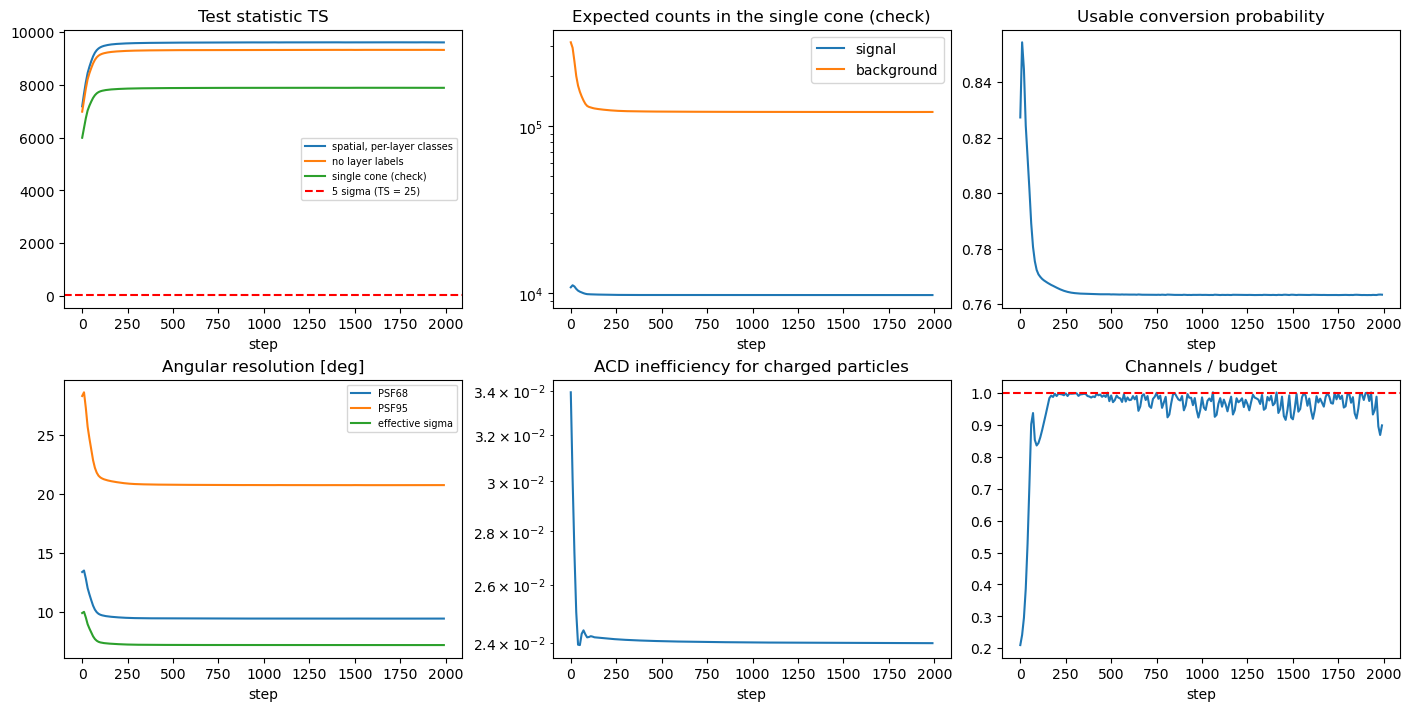

In [9]:
stepNumbers = np.arange(len(optimisationHistory["metrics"])) * recordingInterval
metricsOverSteps = {
    metricName: np.array([recordedEntryAtStep[metricName] for recordedEntryAtStep in optimisationHistory["metrics"]]) for metricName in scalarMetricNames
}

performanceFigure, axesGrid = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
significanceAxis, countsAxis, conversionAxis = axesGrid[0]
resolutionAxis, vetoInefficiencyAxis, channelAxis = axesGrid[1]

significanceAxis.plot(stepNumbers, metricsOverSteps["testStatistic"], label="spatial, per-layer classes")
significanceAxis.plot(stepNumbers, metricsOverSteps["testStatisticNoLabel"], label="no layer labels")
significanceAxis.plot(stepNumbers, metricsOverSteps["coneTestStatistic"], label="single cone (check)")
significanceAxis.axhline(detectionTestStatistic, color="red", linestyle="--", label="5 sigma (TS = 25)")
significanceAxis.set(title="Test statistic TS", xlabel="step")
significanceAxis.legend(fontsize=7)

countsAxis.plot(stepNumbers, metricsOverSteps["signalCount"], label="signal")
countsAxis.plot(stepNumbers, metricsOverSteps["backgroundCount"], label="background")
countsAxis.set(yscale="log", title="Expected counts in the single cone (check)", xlabel="step")
countsAxis.legend()

conversionAxis.plot(stepNumbers, metricsOverSteps["totalConversionProbability"])
conversionAxis.set(title="Usable conversion probability", xlabel="step")

resolutionAxis.plot(stepNumbers, metricsOverSteps["psf68"], label="PSF68")
resolutionAxis.plot(stepNumbers, metricsOverSteps["psf95"], label="PSF95")
resolutionAxis.plot(stepNumbers, metricsOverSteps["angularResolution"], label="effective sigma")
resolutionAxis.set(title="Angular resolution [deg]", xlabel="step")
resolutionAxis.legend(fontsize=7)

vetoInefficiencyAxis.plot(stepNumbers, 1.0 - metricsOverSteps["vetoEfficiency"])
vetoInefficiencyAxis.set(yscale="log", title="ACD inefficiency for charged particles", xlabel="step")

channelAxis.plot(stepNumbers, metricsOverSteps["numberOfChannels"] / channelBudget)
channelAxis.axhline(1.0, color="red", linestyle="--")   # Above this line the channel budget is violated.
channelAxis.set(title="Channels / budget", xlabel="step")
plt.show()

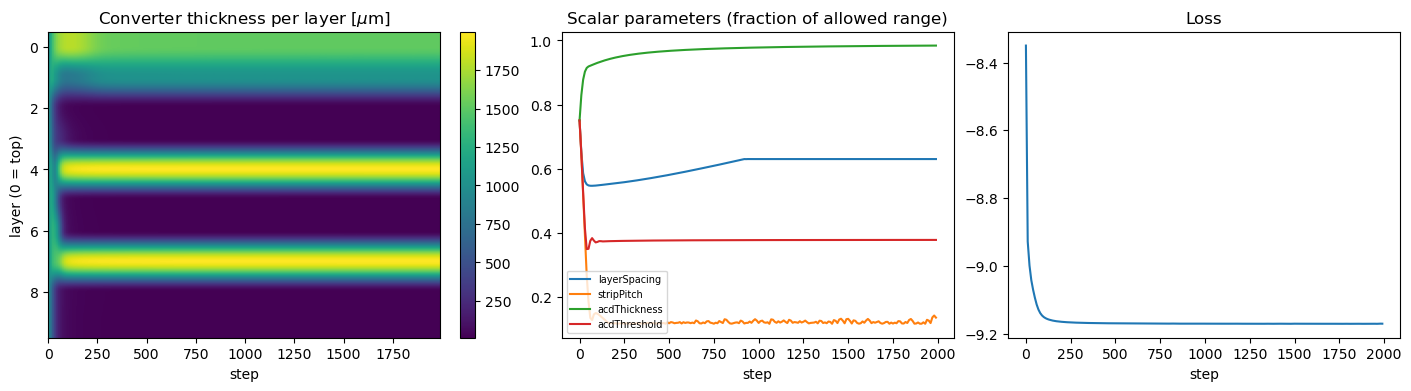

In [10]:
# How the parameters moved. Scalars are shown as a fraction of their allowed range so they share one drawingAxis.
converterThicknessHistory = np.array(
    [recordedEntryAtStep["converterThickness"] for recordedEntryAtStep in optimisationHistory["physicalParameters"]]
)
parameterFigure, (heatmapAxis, scalarParameterAxis, lossAxis) = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

micrometersPerCentimeter = 1e4
heatmapImage = heatmapAxis.imshow(
    converterThicknessHistory.T * micrometersPerCentimeter, aspect="auto", origin="lower",
    extent=[0, stepNumbers[-1], -0.5, numberOfLayers - 0.5],
)
heatmapAxis.set(title=r"Converter thickness per layer [$\mu$m]", xlabel="step", ylabel="layer (0 = top)")
heatmapAxis.invert_yaxis()
plt.colorbar(heatmapImage, ax=heatmapAxis)

for parameterName in ("layerSpacing", "stripPitch", "acdThickness", "acdThreshold"):
    parameterOverSteps = np.array([recordedEntryAtStep[parameterName] for recordedEntryAtStep in optimisationHistory["physicalParameters"]])
    lowerBound, upperBound = parameterBounds[parameterName]
    scalarParameterAxis.plot(stepNumbers, (parameterOverSteps - lowerBound) / (upperBound - lowerBound), label=parameterName)
scalarParameterAxis.set(title="Scalar parameters (fraction of allowed range)", xlabel="step")
scalarParameterAxis.legend(fontsize=7)

lossAxis.plot(stepNumbers, optimisationHistory["loss"])
lossAxis.set(title="Loss", xlabel="step")
plt.show()

## Design views
Converter thickness is drawn 20x thicker than real so it is visible, and the labels give the real tungsten thickness.
A foil thinner than a pixel, even when drawn 20x, shows only as its outline: the outline is a line, not a thickness.
The ACD is drawn to scale. Both designs share the same axis limits, so they are drawn at the same scale: the
width is fixed by `detectorSideLength` and does not change.

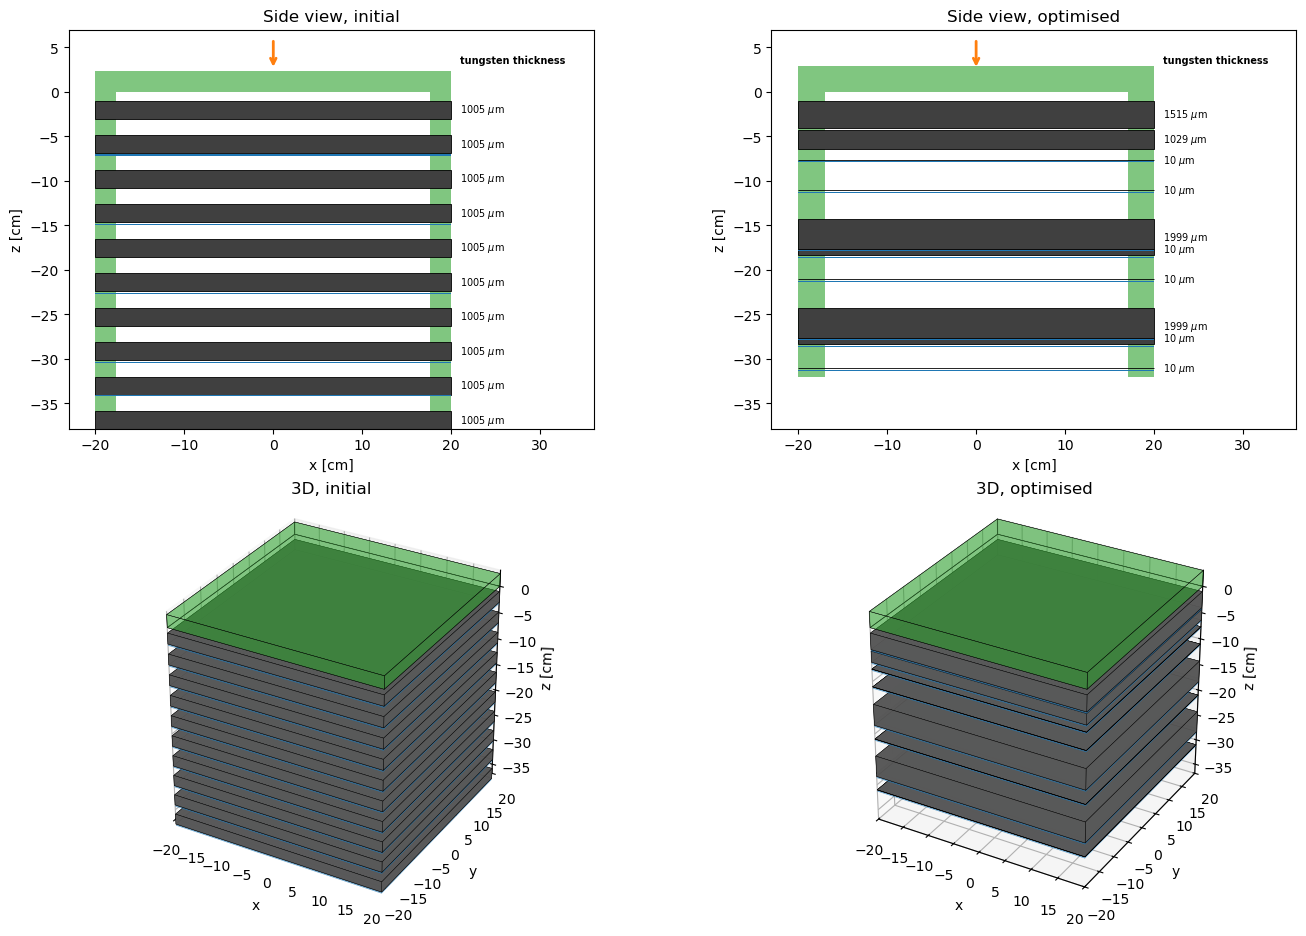

In [11]:
# All numbers in this cell are drawing choices with no physical source.
converterDrawingExaggeration = 20.0   # Converter drawn this many times thicker than real.
siliconPlaneDrawnGap = 0.15         # cm. Distance between the converter and the silicon planes, for drawing only.
siliconPlaneDrawnThickness = 0.05   # cm. For drawing only.
firstLayerDepth = 1.0               # cm. Gap between the top of the ACD and the first converter.
bottomMargin = 1.0                  # cm.
labelMargin = 16.0                  # cm. Space to the right of the tracker for the thickness labels.
micrometersPerCentimeter = 1e4      # Unit conversion.


def computeDrawingGeometry(physicalParameters):
    layerSpacing = float(physicalParameters["layerSpacing"])
    return dict(
        converterDrawnThickness=np.array(physicalParameters["converterThickness"]) * converterDrawingExaggeration,
        acdThickness=float(physicalParameters["acdThickness"]),
        enclosureHeight=firstLayerDepth + (numberOfLayers - 1) * layerSpacing + bottomMargin,
        converterTopHeights=-firstLayerDepth - np.arange(numberOfLayers) * layerSpacing,   # Beam enters at z = 0.
    )


def drawSideView(drawingAxis, physicalParameters, title, axisEnclosureHeight):
    drawingGeometry = computeDrawingGeometry(physicalParameters)
    halfSide = detectorSideLength / 2.0
    acdThickness = drawingGeometry["acdThickness"]
    enclosureHeight = drawingGeometry["enclosureHeight"]

    # ACD: one plate on top and one on each side.
    drawingAxis.add_patch(Rectangle((-halfSide, 0), detectorSideLength, acdThickness, facecolor="tab:green", alpha=0.6))
    drawingAxis.add_patch(Rectangle((-halfSide, -enclosureHeight), acdThickness, enclosureHeight, facecolor="tab:green", alpha=0.6))
    drawingAxis.add_patch(Rectangle((halfSide - acdThickness, -enclosureHeight), acdThickness, enclosureHeight, facecolor="tab:green", alpha=0.6))

    for layerIndex, converterTop in enumerate(drawingGeometry["converterTopHeights"]):
        converterThicknessDrawn = drawingGeometry["converterDrawnThickness"][layerIndex]
        drawingAxis.add_patch(Rectangle((-halfSide, converterTop - converterThicknessDrawn), detectorSideLength, converterThicknessDrawn, facecolor="0.25", edgecolor="black", linewidth=0.6))   # The outline keeps very thin foils visible. 0.6 pt: drawing only.
        realThickness = float(physicalParameters["converterThickness"][layerIndex]) * micrometersPerCentimeter
        drawingAxis.text(halfSide + 1.0, converterTop - converterThicknessDrawn / 2.0, rf"{realThickness:.0f} $\mu$m", va="center", fontsize=7)   # 1.0 cm and font size: drawing only.
        # Two silicon planes (x and y strips) below each converter.
        for planeNumber in (1, 2):
            planeBottom = converterTop - converterThicknessDrawn - planeNumber * siliconPlaneDrawnGap
            drawingAxis.add_patch(Rectangle((-halfSide, planeBottom), detectorSideLength, siliconPlaneDrawnThickness, facecolor="tab:blue"))

    drawingAxis.text(halfSide + 1.0, 3.0, "tungsten thickness", fontsize=7, fontweight="bold", va="bottom")   # Column header for the labels. 3.0 cm and font size: drawing only.
    drawingAxis.annotate("", xy=(0, 2.5), xytext=(0, 6), arrowprops=dict(arrowstyle="->", color="tab:orange", lw=2))   # Beam.
    # The limits come from the shared height, not from this design, so both panels have the same scale.
    drawingAxis.set(xlim=(-halfSide - 3, halfSide + labelMargin), ylim=(-axisEnclosureHeight - 1, 7), aspect="equal",
             title=title, xlabel="x [cm]", ylabel="z [cm]")


def createBoxFaces(xMin, xMax, yMin, yMax, zMin, zMax):
    cornerCoordinates = np.array([
        [xMin, yMin, zMin], [xMax, yMin, zMin], [xMax, yMax, zMin], [xMin, yMax, zMin],
        [xMin, yMin, zMax], [xMax, yMin, zMax], [xMax, yMax, zMax], [xMin, yMax, zMax],
    ])
    faceCornerIndexSets = [[0, 1, 2, 3], [4, 5, 6, 7], [0, 1, 5, 4], [2, 3, 7, 6], [1, 2, 6, 5], [0, 3, 7, 4]]
    return [[cornerCoordinates[cornerIndex] for cornerIndex in cornerIndicesOfFace] for cornerIndicesOfFace in faceCornerIndexSets]


def drawThreeDimensionalView(drawingAxis, physicalParameters, title, axisEnclosureHeight):
    drawingGeometry = computeDrawingGeometry(physicalParameters)
    halfSide = detectorSideLength / 2.0
    enclosureHeight = drawingGeometry["enclosureHeight"]

    for layerIndex, converterTop in enumerate(drawingGeometry["converterTopHeights"]):
        converterThicknessDrawn = drawingGeometry["converterDrawnThickness"][layerIndex]
        converterBottom = converterTop - converterThicknessDrawn
        drawingAxis.add_collection3d(Poly3DCollection(
            createBoxFaces(-halfSide, halfSide, -halfSide, halfSide, converterBottom, converterTop),
            facecolor="0.35", edgecolor="black", linewidth=0.3, alpha=0.9))
        drawingAxis.add_collection3d(Poly3DCollection(
            createBoxFaces(-halfSide, halfSide, -halfSide, halfSide, converterBottom - 0.3, converterBottom - 0.2),
            facecolor="tab:blue", alpha=0.4))

    # Only the top ACD plate is drawn: the side plates would hide the tracker.
    drawingAxis.add_collection3d(Poly3DCollection(
        createBoxFaces(-halfSide, halfSide, -halfSide, halfSide, 0, drawingGeometry["acdThickness"]),
        facecolor="tab:green", edgecolor="black", linewidth=0.3, alpha=0.35))

    drawingAxis.set(xlim=(-halfSide, halfSide), ylim=(-halfSide, halfSide), zlim=(-axisEnclosureHeight, 3),
             title=title, xlabel="x", ylabel="y", zlabel="z [cm]")
    drawingAxis.set_box_aspect((detectorSideLength, detectorSideLength, axisEnclosureHeight + 3))   # 3 cm: room above the ACD, drawing only.
    drawingAxis.quiver(0, 0, 8, 0, 0, -6, color="tab:orange", linewidth=2)   # Beam.


initialPhysicalParameters = mapUnboundedToPhysicalParameters(initialParameters)
optimisedPhysicalParameters = mapUnboundedToPhysicalParameters(optimisedParameters)

# Both designs are drawn with the limits of the taller one, so they are at the same scale.
sharedEnclosureHeight = max(
    computeDrawingGeometry(designParameters)["enclosureHeight"]
    for designParameters in (initialPhysicalParameters, optimisedPhysicalParameters)
)

designFigure = plt.figure(figsize=(14, 9), constrained_layout=True)   # Figure size: drawing only.
for columnIndex, (designParameters, designName) in enumerate(
    [(initialPhysicalParameters, "initial"), (optimisedPhysicalParameters, "optimised")]
):
    drawSideView(designFigure.add_subplot(2, 2, 1 + columnIndex), designParameters, f"Side view, {designName}", sharedEnclosureHeight)
    drawThreeDimensionalView(designFigure.add_subplot(2, 2, 3 + columnIndex, projection="3d"), designParameters, f"3D, {designName}", sharedEnclosureHeight)
plt.show()

## Per-layer comparison

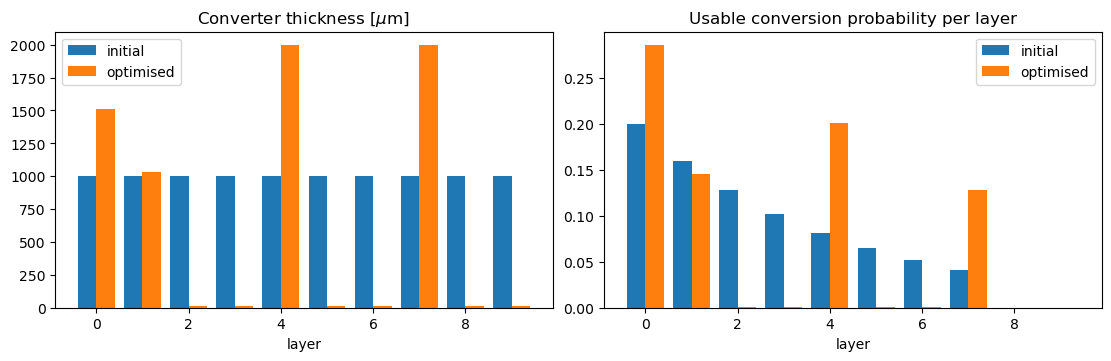

In [12]:
initialResponse = computeMetrics(initialParameters)
optimisedResponse = computeMetrics(optimisedParameters)

layerNumbers = np.arange(numberOfLayers)
barWidth = 0.4
perLayerFigure, (thicknessAxis, conversionPerLayerAxis) = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)

thicknessAxis.bar(layerNumbers - barWidth / 2, np.array(initialPhysicalParameters["converterThickness"]) * micrometersPerCentimeter, barWidth, label="initial")
thicknessAxis.bar(layerNumbers + barWidth / 2, np.array(optimisedPhysicalParameters["converterThickness"]) * micrometersPerCentimeter, barWidth, label="optimised")
thicknessAxis.set(title=r"Converter thickness [$\mu$m]", xlabel="layer")
thicknessAxis.legend()

conversionPerLayerAxis.bar(layerNumbers - barWidth / 2, initialResponse["conversionProbabilityPerLayer"], barWidth, label="initial")
conversionPerLayerAxis.bar(layerNumbers + barWidth / 2, optimisedResponse["conversionProbabilityPerLayer"], barWidth, label="optimised")
conversionPerLayerAxis.set(title="Usable conversion probability per layer", xlabel="layer")
conversionPerLayerAxis.legend()
plt.show()

## Random restarts
The landscape has several local optima, so start from random designs and compare where they end. The plots are grouped:
1. **Summary**: how the test statistic evolves, the final test statistic of each restart grouped into basins (restarts
   that end in the same design), and the scalar parameters each restart chose.
2. **Tungsten per layer, overview**: one row per restart, one column per layer, so the foil patterns can be compared at a glance.
3. **Tungsten per layer, one panel per restart**: the same data as bars, ordered from the best restart to the worst.

Basins (restarts that end at the same test statistic):
  A: TS 9769.5, found by 2 of 10 restarts (seeds [2, 7]), foils [um] [1992   10   10 1998   10   10 1995  677]
  B: TS 9767.7, found by 2 of 10 restarts (seeds [0, 4]), foils [um] [2000   10   11 2000   10   10 1991  676]
  C: TS 9666.5, found by 1 of 10 restarts (seeds [8]), foils [um] [1998   10   10 1716 1034   10   10 1999]
  D: TS 9616.8, found by 3 of 10 restarts (seeds [6, 1, 9]), foils [um] [1514 1029   10   10 1999   10   10 1999]
  E: TS 9615.8, found by 1 of 10 restarts (seeds [5]), foils [um] [1514 1029   10   10 2000   10   10 1998]
  F: TS 9612.8, found by 1 of 10 restarts (seeds [3]), foils [um] [1516 1031   10   10 1999   10   10 1999]
Spread of the final test statistic: 9612.8 to 9769.5


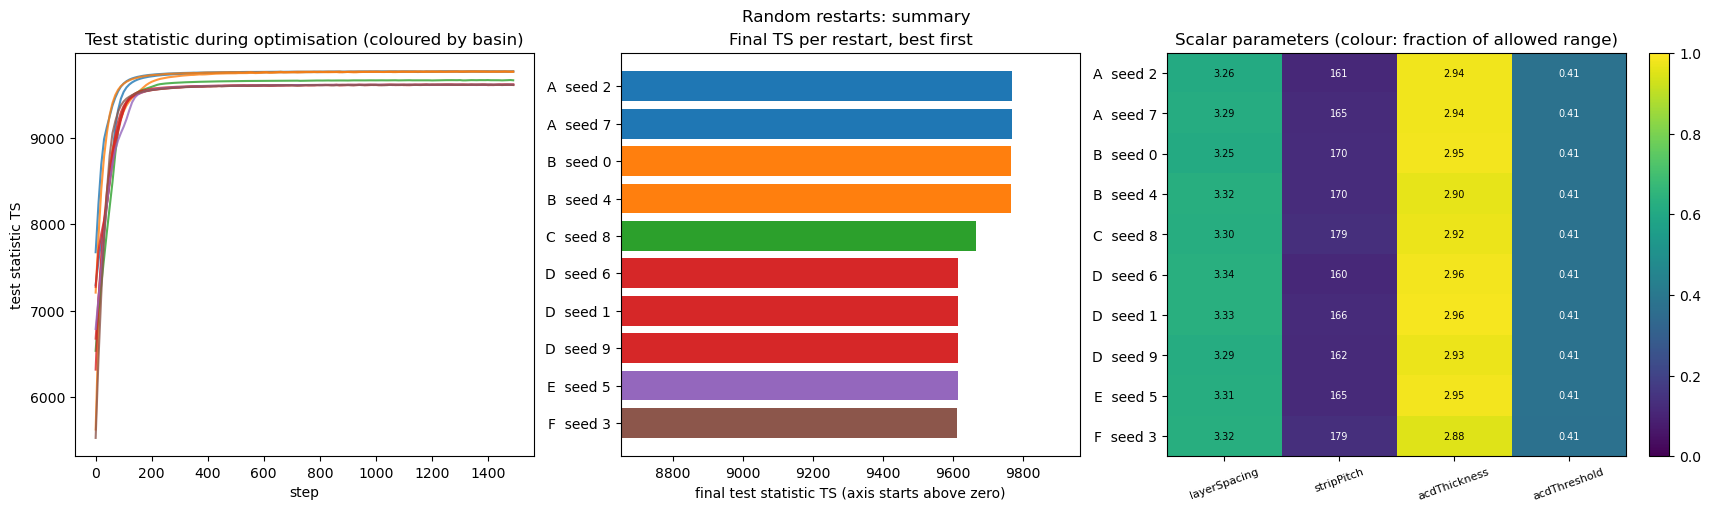

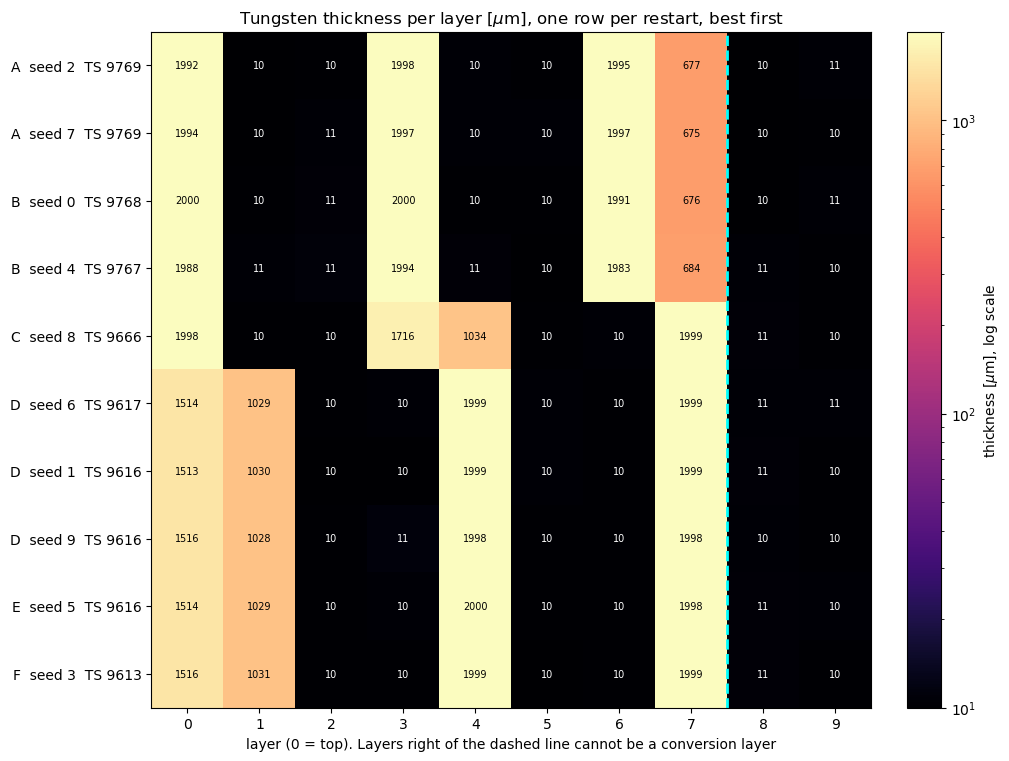

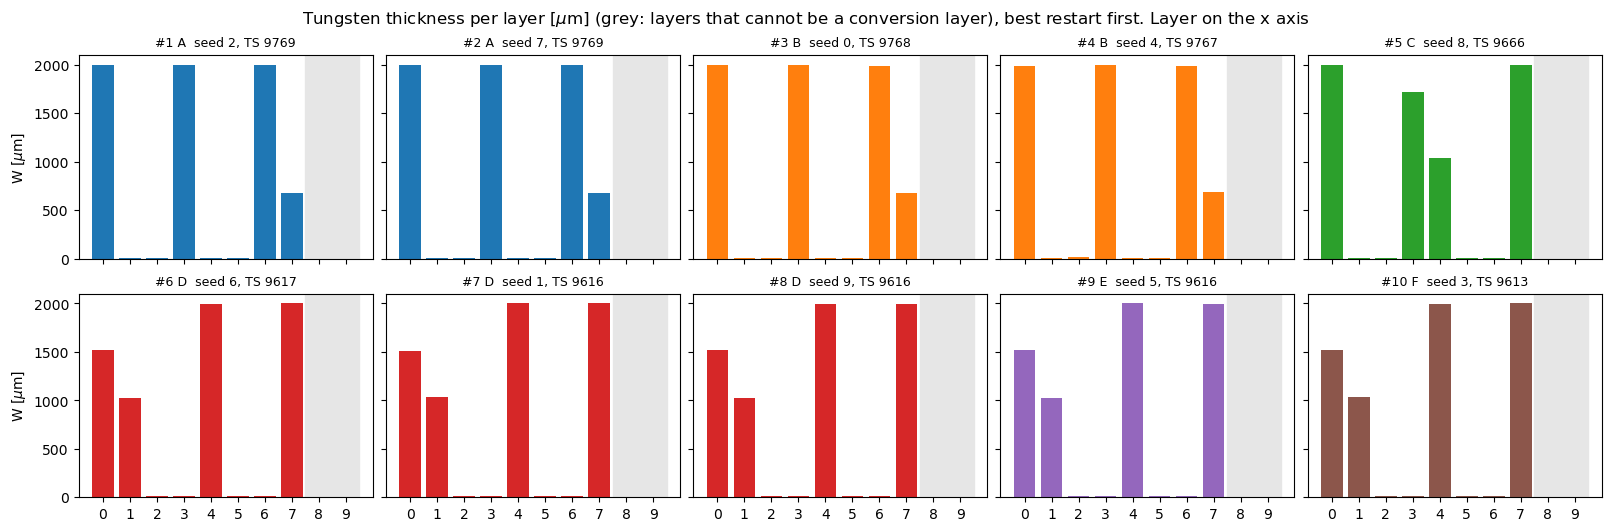

In [13]:
# All plot and grouping settings in this cell (sizes, colours, tolerances) have no physical source.
numberOfRestarts = 10   # Numerical choice.
sameBasinTolerance = 1.0   # Restarts whose final test statistic differs by less than this are put in the same basin. Numerical choice, in units of TS.
# randomSpread=1.5 (spread of the random start in the unbounded space) and numberOfSteps=1500: numerical choices.

restartResults = []
for seedNumber in range(numberOfRestarts):
    restartParameters, restartHistory = runOptimisation(
        createInitialParameters(jax.random.PRNGKey(seedNumber), randomSpread=1.5), numberOfSteps=1500
    )
    restartResults.append(dict(
        seed=seedNumber,
        testStatistic=float(computeMetrics(restartParameters)["testStatistic"]),
        history=restartHistory,
        physicalParameters={name: np.array(value) for name, value in mapUnboundedToPhysicalParameters(restartParameters).items()},
    ))
restartResults.sort(key=lambda result: -result["testStatistic"])   # Best restart first.

# Group the restarts into basins: a new basin starts when the test statistic is lower than the basin's best by more than the tolerance.
basinLabels = []
for rank, result in enumerate(restartResults):
    if rank == 0 or restartResults[rank - 1]["basinStart"] - result["testStatistic"] > sameBasinTolerance:
        result["basinStart"] = result["testStatistic"]
        basinLabels.append(chr(ord("A") + len(basinLabels)))
    else:
        result["basinStart"] = restartResults[rank - 1]["basinStart"]
    result["basin"] = basinLabels[-1]
basinColors = {label: plt.cm.tab10(index) for index, label in enumerate(basinLabels)}   # tab10: ten distinguishable colours.

print("Basins (restarts that end at the same test statistic):")
for label in basinLabels:
    members = [result for result in restartResults if result["basin"] == label]
    foils = np.round(members[0]["physicalParameters"]["converterThickness"] * micrometersPerCentimeter).astype(int)
    print(f"  {label}: TS {members[0]['testStatistic']:6.1f}, found by {len(members)} of {numberOfRestarts} restarts (seeds {[m['seed'] for m in members]}), foils [um] {foils[:numberOfReconstructableLayers]}")
print(f"Spread of the final test statistic: {restartResults[-1]['testStatistic']:.1f} to {restartResults[0]['testStatistic']:.1f}")

restartLabels = [f"{result['basin']}  seed {result['seed']}" for result in restartResults]
layerNumbers = np.arange(numberOfLayers)
foilLower, foilUpper = (bound * micrometersPerCentimeter for bound in parameterBounds["converterThickness"])
foilMatrix = np.array([result["physicalParameters"]["converterThickness"] * micrometersPerCentimeter for result in restartResults])

# 1. Summary.
summaryFigure, (trajectoryAxis, finalAxis, scalarAxis) = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
for result in restartResults:
    trajectoryAxis.plot(np.arange(len(result["history"]["metrics"])) * recordingInterval,
                        [entry["testStatistic"] for entry in result["history"]["metrics"]], color=basinColors[result["basin"]], alpha=0.8)
trajectoryAxis.set(xlabel="step", ylabel="test statistic TS", title="Test statistic during optimisation (coloured by basin)")
finalAxis.barh(np.arange(numberOfRestarts), [result["testStatistic"] for result in restartResults], color=[basinColors[result["basin"]] for result in restartResults])
finalAxis.set_yticks(np.arange(numberOfRestarts), restartLabels)
finalAxis.invert_yaxis()
finalAxis.set_xlim(0.9 * restartResults[-1]["testStatistic"], 1.02 * restartResults[0]["testStatistic"])   # Zoomed: the spread is a few per cent.
finalAxis.set(xlabel="final test statistic TS (axis starts above zero)", title="Final TS per restart, best first")
scalarNames = ("layerSpacing", "stripPitch", "acdThickness", "acdThreshold")
scalarFractions = np.array([[(float(result["physicalParameters"][name]) - parameterBounds[name][0]) / (parameterBounds[name][1] - parameterBounds[name][0])
                             for name in scalarNames] for result in restartResults])
scalarImage = scalarAxis.imshow(scalarFractions, aspect="auto", vmin=0.0, vmax=1.0, cmap="viridis")
scalarAxis.set_xticks(np.arange(len(scalarNames)), scalarNames, rotation=20, fontsize=8)
scalarAxis.set_yticks(np.arange(numberOfRestarts), restartLabels)
for row, result in enumerate(restartResults):
    for column, name in enumerate(scalarNames):
        value = float(result["physicalParameters"][name]) * (micrometersPerCentimeter if name == "stripPitch" else 1.0)
        scalarAxis.text(column, row, f"{value:.2f}" if name != "stripPitch" else f"{value:.0f}", ha="center", va="center", fontsize=7, color="white" if scalarFractions[row, column] < 0.6 else "black")   # 0.6: text colour switch.
scalarAxis.set(title="Scalar parameters (colour: fraction of allowed range)")
plt.colorbar(scalarImage, ax=scalarAxis)
summaryFigure.suptitle("Random restarts: summary")
plt.show()

# 2. Tungsten per layer, overview.
overviewFigure, overviewAxis = plt.subplots(figsize=(10, 0.55 * numberOfRestarts + 2), constrained_layout=True)
overviewImage = overviewAxis.imshow(foilMatrix, aspect="auto", cmap="magma", norm=LogNorm(vmin=foilLower, vmax=foilUpper))
overviewAxis.set_xticks(layerNumbers, [str(layer) for layer in layerNumbers])
overviewAxis.set_yticks(np.arange(numberOfRestarts), [f"{label}  TS {result['testStatistic']:.0f}" for label, result in zip(restartLabels, restartResults)])
for row in range(numberOfRestarts):
    for column in range(numberOfLayers):
        overviewAxis.text(column, row, f"{foilMatrix[row, column]:.0f}", ha="center", va="center", fontsize=7,
                          color="white" if foilMatrix[row, column] < np.sqrt(foilLower * foilUpper) else "black")   # Dark cells are thin foils: white text there, black on the bright thick ones. Switch at the middle of the log range.
overviewAxis.axvline(numberOfReconstructableLayers - 0.5, color="cyan", linestyle="--", linewidth=2)   # Layers to the right cannot be a conversion layer. Cyan shows on both the dark and the bright cells.
overviewAxis.set(xlabel="layer (0 = top). Layers right of the dashed line cannot be a conversion layer", title=r"Tungsten thickness per layer [$\mu$m], one row per restart, best first")
plt.colorbar(overviewImage, ax=overviewAxis, label=r"thickness [$\mu$m], log scale")
plt.show()

# 3. Tungsten per layer, one panel per restart.
numberOfColumns = 5   # Panels per row.
numberOfRows = int(np.ceil(numberOfRestarts / numberOfColumns))
panelsFigure, panelAxes = plt.subplots(numberOfRows, numberOfColumns, figsize=(3.2 * numberOfColumns, 2.6 * numberOfRows), sharex=True, sharey=True, constrained_layout=True)
for panelIndex, panelAxis in enumerate(np.atleast_1d(panelAxes).ravel()):
    if panelIndex >= numberOfRestarts:
        panelAxis.axis("off"); continue
    result = restartResults[panelIndex]
    panelAxis.bar(layerNumbers, foilMatrix[panelIndex], color=basinColors[result["basin"]])
    panelAxis.axvspan(numberOfReconstructableLayers - 0.5, numberOfLayers - 0.5, color="0.9")   # Layers that cannot be a conversion layer.
    panelAxis.set_title(f"#{panelIndex + 1} {restartLabels[panelIndex]}, TS {result['testStatistic']:.0f}", fontsize=9)
    panelAxis.set_xticks(layerNumbers)
for panelAxis in np.atleast_1d(panelAxes)[:, 0] if numberOfRows > 1 else [np.atleast_1d(panelAxes)[0]]:
    panelAxis.set_ylabel(r"W [$\mu$m]")
panelsFigure.suptitle(r"Tungsten thickness per layer [$\mu$m] (grey: layers that cannot be a conversion layer), best restart first. Layer on the x axis")
plt.show()